<a href="https://colab.research.google.com/github/11js05/Celebel_assignments/blob/main/week5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)


TensorFlow: 2.20.0


In [ ]:
corpus = '''
Global warming refers to the gradual increase in the Earth's average temperature due to the accumulation of greenhouse gases in the atmosphere. These gases, mainly carbon dioxide (CO₂), methane, and nitrous oxide, trap heat from the sun and create the greenhouse effect. While this effect is essential for maintaining life on Earth, excessive greenhouse gas emissions have led to a significant rise in global temperatures.
Human activities are the primary cause of global warming. The burning of fossil fuels for electricity, transportation, and industrial purposes releases large amounts of carbon dioxide into the atmosphere. Deforestation further worsens the problem because trees absorb carbon dioxide and help regulate the climate. Agricultural activities and industrial processes also contribute to greenhouse gas emissions.
The effects of global warming are becoming increasingly visible. Rising temperatures are causing glaciers and polar ice caps to melt, leading to higher sea levels. Extreme weather events such as heat waves, droughts, floods, and hurricanes are occurring more frequently. Global warming also threatens biodiversity, as many plant and animal species struggle to adapt to changing environmental conditions.
The impact on human life is significant. Climate change can affect agriculture, reduce water availability, increase health risks, and damage infrastructure. These challenges can lead to economic losses and reduced quality of life for millions of people.
To combat global warming, governments, industries, and individuals must work together. Using renewable energy sources, conserving energy, reducing waste, planting trees, and promoting sustainable practices can help reduce greenhouse gas emissions. International efforts such as the Paris Agreement also play an important role in addressing climate change.
In conclusion, global warming is a serious global issue that requires immediate action to protect the environment and ensure a sustainable future for coming generations.
'''
print(corpus)


Global warming refers to the gradual increase in the Earth's average temperature due to the accumulation of greenhouse gases in the atmosphere. These gases, mainly carbon dioxide (CO₂), methane, and nitrous oxide, trap heat from the sun and create the greenhouse effect. While this effect is essential for maintaining life on Earth, excessive greenhouse gas emissions have led to a significant rise in global temperatures.
Human activities are the primary cause of global warming. The burning of fossil fuels for electricity, transportation, and industrial purposes releases large amounts of carbon dioxide into the atmosphere. Deforestation further worsens the problem because trees absorb carbon dioxide and help regulate the climate. Agricultural activities and industrial processes also contribute to greenhouse gas emissions.
The effects of global warming are becoming increasingly visible. Rising temperatures are causing glaciers and polar ice caps to melt, leading to higher sea levels. Extr

In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 179
X shape: (281, 64)
y shape: (281,)


In [ ]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


In [ ]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


In [ ]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


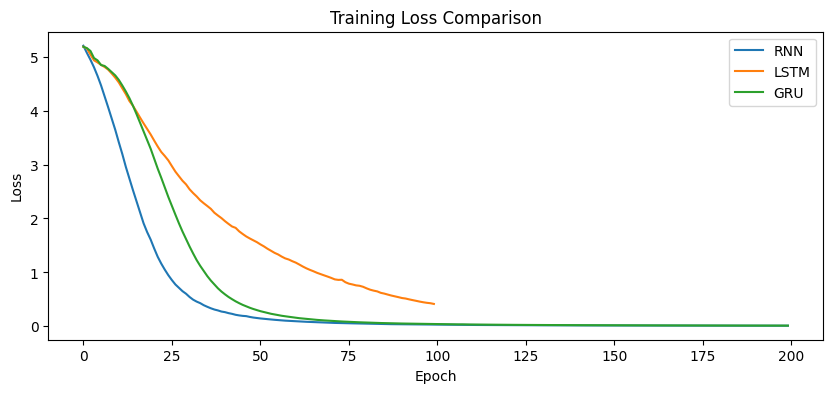

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

In [ ]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

In [ ]:
print("RNN :", generate_text(rnn_model, "Global Warming", 10))
print("LSTM:", generate_text(lstm_model, "Global Warming", 10))
print("GRU :", generate_text(gru_model, "Global Warming", 10))

RNN : Global Warming refers to the gradual increase in the earth's average temperature
LSTM: Global Warming refers to the gradual increase in the earth's average temperature
GRU : Global Warming refers to the gradual increase in the earth's average temperature
